In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.stats import sigma_clip
# from astropy.modeling.models import Polynomial1D

from prism.data import Cube
import prism.modeling.fitting as fitting
from prism.modeling.models import FixedTemplate, BSpline

In [2]:
# Load the data cube
filename = "data/datacube.fits"
cube = Cube.from_fits(filename)

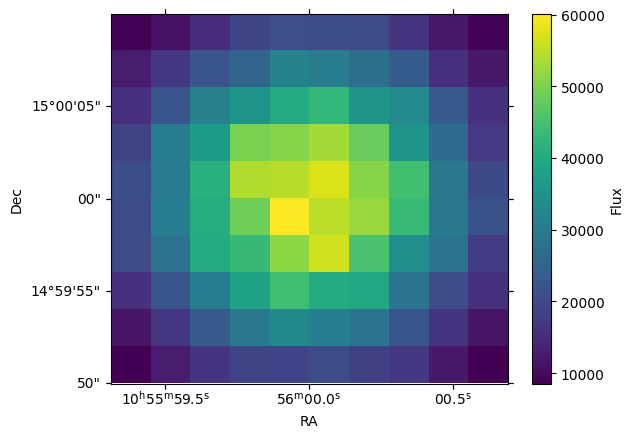

In [3]:
img = cube.to_image() # Collapse spectral axis to get 2D image

fig, ax = plt.subplots(subplot_kw={'projection': cube.wcs.celestial})

ax.imshow(img.data, origin="lower", aspect="auto", cmap="viridis")
fig.colorbar(ax.images[0], ax=ax, label="Flux")

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
plt.show()

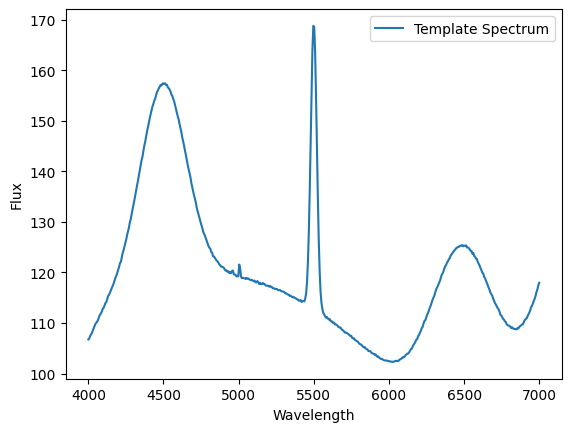

In [4]:
# Take the brightest pixel as template
brightest_pixel = np.unravel_index(np.argmax(img.data), img.data.shape)
template_spectrum = cube.data[:, brightest_pixel[0], brightest_pixel[1]]
template_error = cube.err[:, brightest_pixel[0], brightest_pixel[1]]

plt.figure()
plt.plot(cube.wave, template_spectrum, label="Template Spectrum")
plt.xlabel("Wavelength")
plt.ylabel("Flux")
plt.legend()
plt.show()

In [5]:
# Build the model as:
# model = a(λ) * template
# As a(λ) we use a B-spline to allow for smooth variations across the field and avoid polynomial artifacts at the edges.

# Define the model
# Setup cubic BSpline constants
degree = 3  # Cubic spline
nknots = 5  # Number of internal knots

# Total knots = internal knots + 2*degree (for endpoint padding)
knots = np.concatenate((
    [cube.wave[0]] * degree,
    np.linspace(cube.wave[0], cube.wave[-1], nknots),
    [cube.wave[-1]] * degree
))
ncoeffs = len(knots) - degree - 1  # Number of B-spline coefficients (fit parameters)

spline = BSpline(knots, degree, name="spline")
template = FixedTemplate(cube.wave, template_spectrum)

# model = spline * template



# If you want you can add wathever additional components to the model
# e.g. additional Polynomial or Gaussian lines to capture specific features not in the template.
# poly = Polynomial1D(degree=3)
# We migh also add another additive spline.

degree = 3  # Cubic spline
nknots = 3
knots = np.concatenate((
    [cube.wave[0]] * degree,
    np.linspace(cube.wave[0], cube.wave[-1], nknots),
    [cube.wave[-1]] * degree
))
ncoeffs = len(knots) - degree - 1  # Number of B-spline coefficients (fit parameters)

aspline = BSpline(knots, degree, name="aspline")


model = spline * template + aspline

In [6]:
# Let's fit with iterative outlier removal to get rid iteratively of outliers.
# In some cases additional narrow lines can be ouliers wrt the reshaped template!
# Clipping them we imporve a lot the performances!

outlier_fitter = fitting.FittingWithOutlierRemoval(
    fitter=fitting.SherpaLM(), 
    outlier_func=sigma_clip, 
    niter=3, 
    sigma_lower=3.0,
    sigma_upper=2.0
)
# NOTE: # If we expect outliers to be positive (e.g. emission lines),
# we can set a low lower sigma threshold to avoid clipping features we want to include in the template!

In [7]:
# Run over the whole cube synchronously
fitted_model = outlier_fitter(
    model, cube.wave, cube.data, yerr=cube.err,
    nproc=1, # For larger cubes you can parallelize the fitting across multiple cores with nproc > 1
)

Fitting spectra:   0%|          | 0/100 [00:00<?, ?it/s]

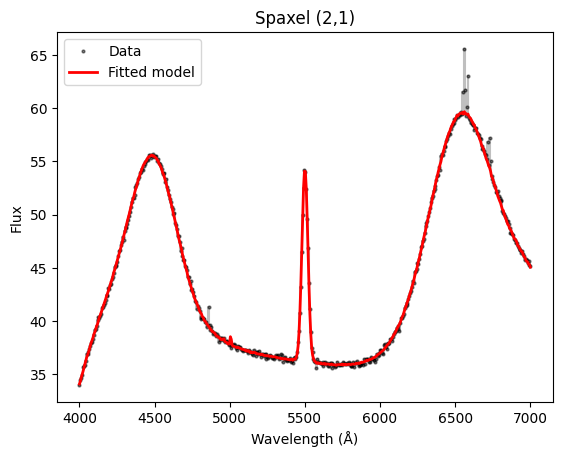

In [8]:
# Extract one spaxel and verify visually
j, i = 2, 1

modelij = fitted_model[j, i].model
y_fit = modelij(cube.wave)

plt.figure()

plt.plot(cube.wave, cube.data[:, j, i], drawstyle='steps-mid', color='gray', alpha=0.5)
plt.plot(cube.wave, cube.data[:, j, i], 'k.', markersize=4, alpha=0.5, label='Data')
plt.plot(cube.wave, y_fit, 'r-', lw=2, label='Fitted model')

plt.title(f"Spaxel ({j},{i})")
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")
plt.legend()
plt.show()

In [9]:
# Subtract the fitted model from the data to get the residuals
residuals = cube - fitted_model(cube.wave)

# Now we could also propagate the uncertainty form the fit
# The error can be estimated as var = var_data + (std_reference*spline)**2

splinecube = fitted_model.comps["spline"](cube.wave) # With .comps we can access the individual components of the model!

resvar = cube.var + (template_error[:, np.newaxis, np.newaxis] * splinecube)**2
residuals.var = resvar

# Mask the template spaxel
residuals.mask = np.ones(cube.data.shape, dtype=bool)
residuals.mask[:, brightest_pixel[0], brightest_pixel[1]] = False

type(residuals) # Operations on Cube objects preserve the Cube type, so we keep all the metadata and WCS information in the residuals!

prism.data.cube.Cube

In [10]:
# Save the results
residuals.write(
    "results/rescube.fits",
    cd_matrix=True,
    overwrite=True
)